### Exploritory notebook for data processing

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray

from src.utils.paths import INTERM_DATA_DIR, PROCESSED_DATA_DIR, RAW_DATA_DIR

In [ ]:
# Load soil moisture data
sm_dir = RAW_DATA_DIR / "SMAP_1km"
sm_files = sorted(sm_dir.glob("NSIDC-0779_*.tif"))
sm_f = sm_files[7]

sm_da = rioxarray.open_rasterio(sm_f)

print(sm_da)

<xarray.DataArray (band: 2, y: 14616, x: 34704)> Size: 4GB
[1014467328 values with dtype=float32]
Coordinates:
  * band         (band) int64 16B 1 2
  * y            (y) float64 117kB 7.314e+06 7.313e+06 ... -7.313e+06 -7.314e+06
  * x            (x) float64 278kB -1.737e+07 -1.737e+07 ... 1.737e+07 1.737e+07
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0.0
    scale_factor:   1.0
    add_offset:     0.0


In [4]:
# Load shapefiles
shapefile_proc_dir = INTERM_DATA_DIR / "shapefiles"

hokkaido_shape = gpd.read_file(shapefile_proc_dir / "hokkaido_shape.shp")
kushiro_shape = gpd.read_file(shapefile_proc_dir / "kushiro_shape.shp")

In [ ]:
# Trim soil moisture data to Hokkaido and Kushiro Basin using shapefiles

# check for matching crs
if sm_da.rio.crs != hokkaido_shape.crs:
    hokkaido_shape = hokkaido_shape.to_crs(sm_da.rio.crs)
    print("converted hokkaido shapefile to sm crs")
if sm_da.rio.crs != kushiro_shape.crs:
    kushiro_shape = kushiro_shape.to_crs(sm_da.rio.crs)
    print("converted kushiro shapefile to sm crs")

# trim
sm_hokkaido = sm_da.rio.clip(hokkaido_shape.geometry, hokkaido_shape.crs, drop=True)
print("trimmed sm to Hokkaido")

sm_kushiro = sm_da.rio.clip(kushiro_shape.geometry, kushiro_shape.crs, drop=True)
print("trimmed sm to Kushiro Basin")

converted hokkaido shapefile to sm crs
converted kushiro shapefile to sm crs
trimmed sm to Hokkaido
trimmed sm to Kushiro Basin


In [6]:
print(sm_hokkaido)
print(sm_hokkaido.band.values)
print(sm_hokkaido.attrs)

<xarray.DataArray (band: 2, y: 424, x: 660)> Size: 2MB
array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]],
      shape=(2, 424, 660), dtype=float32)
Coordinates:
  * band         (band) int64 16B 1 2
  * y            (y) float64 3kB 5.243e+06 5.242e+06 ... 4.821e+06 4.82e+06
  * x            (x) float64 5kB 1.342e+07 1.342e+07 ... 1.408e+07 1.408e+07
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     0.0
[1 2]
{'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset

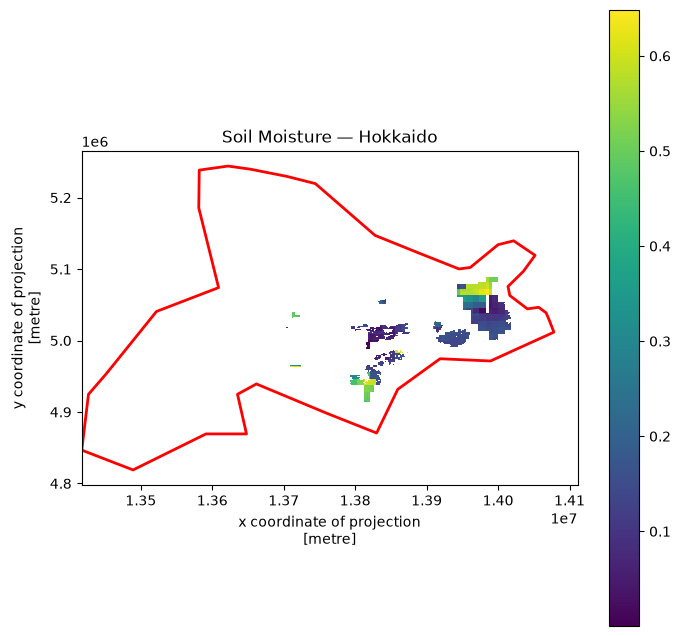

In [ ]:
sm_plot = sm_hokkaido.sel(band=1).where(sm_hokkaido.sel(band=1) != 0)

fig, ax = plt.subplots(figsize=(8, 8))

sm_plot.plot.imshow(ax=ax, cmap="viridis")

hokkaido_shape.boundary.plot(ax=ax, color="red", linewidth=2)

ax.set_aspect("equal")
ax.set_title("Soil Moisture — Hokkaido")

plt.show()

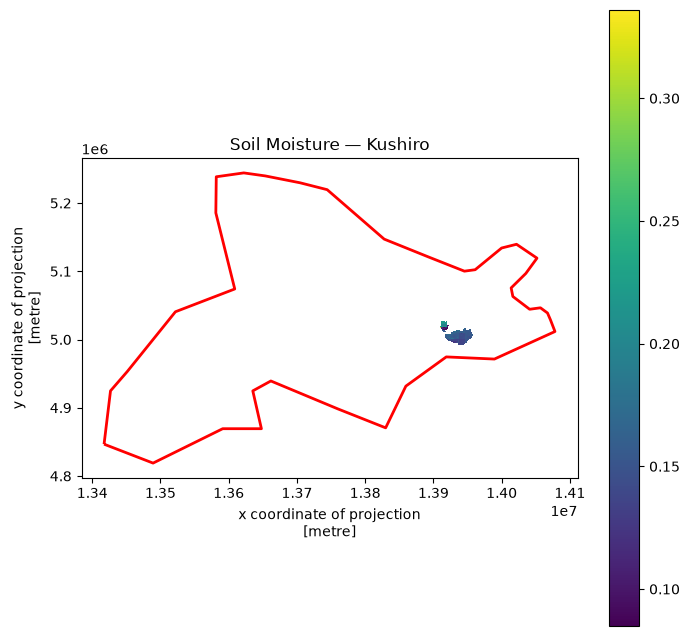

In [ ]:
sm_plot = sm_kushiro.sel(band=1).where(sm_kushiro.sel(band=1) != 0)

fig, ax = plt.subplots(figsize=(8, 8))

sm_plot.plot.imshow(ax=ax, cmap="viridis")

hokkaido_shape.boundary.plot(ax=ax, color="red", linewidth=2)

ax.set_aspect("equal")
ax.set_title("Soil Moisture — Kushiro")

plt.show()